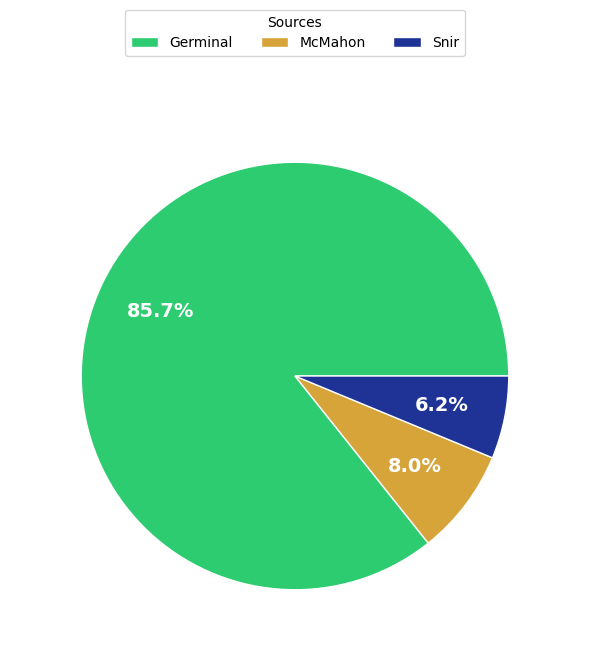

In [29]:
# bar chart ?
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Define data
data = {'Germinal': 480, 'McMahon': 45, 'Snir': 35}
labels = list(data.keys())
values = list(data.values())

# 2. Setup colors
colors_dict = {'Germinal': "#2ecc71", 'McMahon': "#d6a439", 'Snir': "#1f3397"}
colors = [colors_dict[label] for label in labels]

plt.style.use('default')
fig, ax = plt.subplots(figsize=(6, 7)) 

# 3. Plotting
# labels=None is used here so they only appear in the legend
wedges, texts, autotexts = ax.pie(values, colors=colors, radius=3, center=(4, 4),
                                 wedgeprops={"linewidth": 1, "edgecolor": "white"}, 
                                 frame=False, autopct='%1.1f%%', pctdistance=0.7)

ax.set(xlim=(0, 8), ylim=(0, 8))
ax.set_xticks([])
ax.set_yticks([])

plt.setp(autotexts, size=14, weight="bold", color="white")

# 4. Legend positioning

ax.legend(
    wedges, 
    labels, 
    title="Sources",
    loc="lower center",  # Anchors the bottom of the legend box
    bbox_to_anchor=(0.5, 1.05),  # Places it right above the upper plot boundary
    ncol=3,
    frameon=True,
)

plt.tight_layout()
plt.show()

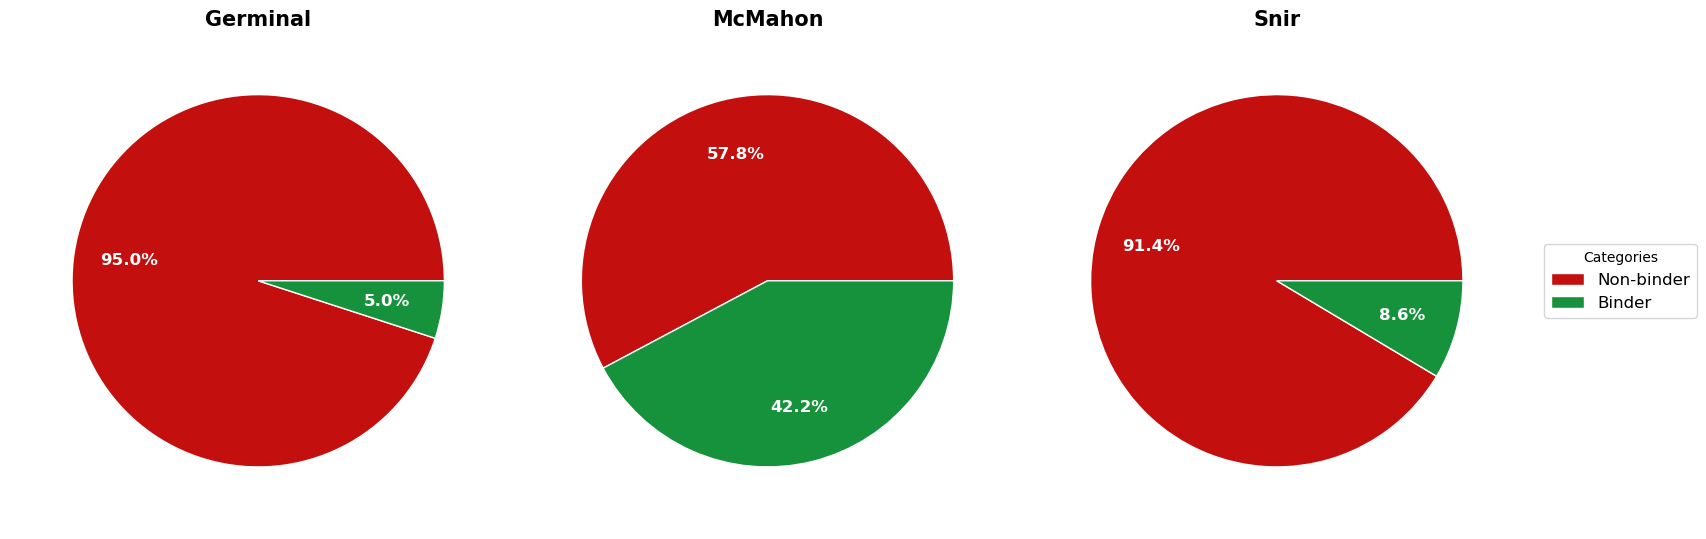

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the Data
data = {
    'Non-binder': [456, 26, 32],
    'Binder': [24, 19, 3]
}
sources = ['Germinal', 'McMahon', 'Snir']
df = pd.DataFrame(data, index=sources)

# 2. Setup Plot
# Binder = Green, Non-binder = Red
colors = ["#c40f0f", "#17923c"] 

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, source in enumerate(sources):
    ax = axes[i]
    values = df.loc[source].values
    
    # Draw the pie - labels=None to keep them out of the pie itself
    wedges, texts, autotexts = ax.pie(values, colors=colors, radius=3, center=(4, 4),
                                     wedgeprops={"linewidth": 1, "edgecolor": "white"}, 
                                     frame=False, autopct='%1.1f%%', pctdistance=0.7)

    ax.set_title(f"{source}", size=15, weight="bold", pad=5)
    
    # Remove grid and ticks
    ax.set(xlim=(0, 8), ylim=(0, 8))
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Optional: Make percentage text white for better contrast
    plt.setp(autotexts, size=12, weight="bold", color="white")

# Add the legend to the right side of the entire figure
fig.legend(wedges, df.columns, fontsize=12, title="Categories", loc="center right", bbox_to_anchor=(0.95, 0.5))

plt.tight_layout()
plt.subplots_adjust(right=0.85) # Make room for the legend
plt.show()

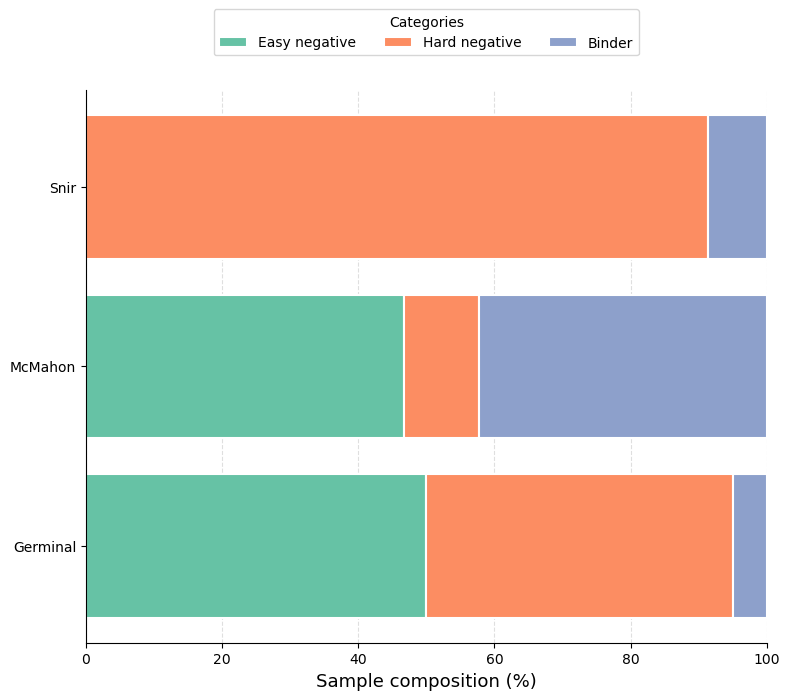

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Data
data = {
    "Easy negative": [240, 21, 0],
    "Hard negative": [216, 5, 32],
    "Binder": [24, 19, 3],
}

sources = ["Germinal", "McMahon", "Snir"]
df = pd.DataFrame(data, index=sources)

# Normalize to %
df_rel = df.div(df.sum(axis=1), axis=0) * 100

colors = sns.color_palette("Set2")
#colors = ["#7d4da3", "#5058c5", "#4cb696"]

fig, ax = plt.subplots(figsize=(8, 7.5))

left = np.zeros(len(df_rel))

for i, column in enumerate(df_rel.columns):
    bars = ax.barh(
        df_rel.index,
        df_rel[column],
        left=left,
        label=column,
        color=colors[i],
        edgecolor="white",
        linewidth=1.5,
    )
    left += df_rel[column].values



ax.set_xlabel("Sample composition (%)", fontsize=13)
ax.set_xlim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# LEGEND (Positioned directly under the title, above the plot)
ax.legend(
    title="Categories",
    loc="lower center",  # Anchors the bottom of the legend box
    bbox_to_anchor=(0.5, 1.05),  # Places it right above the upper plot boundary
    ncol=3,
    frameon=True,
)

plt.tight_layout()
# Leaves enough padding at the top for both the title and the legend
plt.subplots_adjust(top=0.82)

plt.show()